In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

In [32]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None) 
df_datos_salud_visu = pd.read_csv("df_datos_salud_clean.csv", index_col=0)

## _1-¿Como se distribuye el IMC por población?_

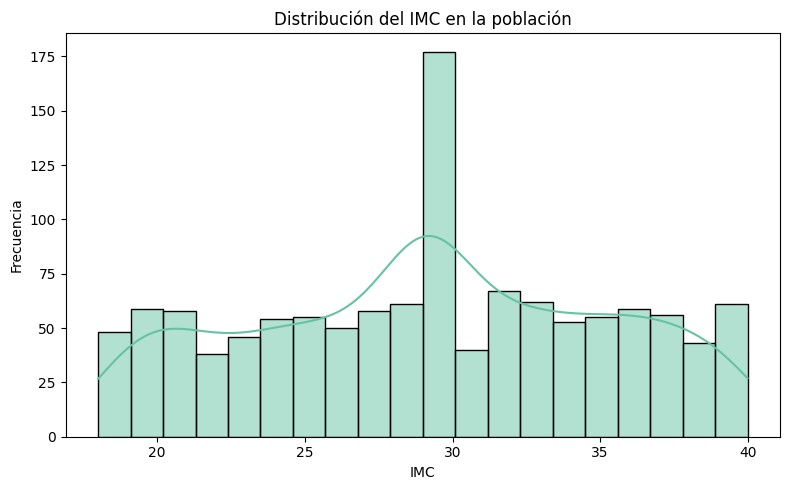

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_datos_salud_visu['imc'],
    bins=20,
    kde=True,
    color=sns.color_palette('Set2')[0]
)
plt.title("Distribución del IMC en la población")
plt.xlabel("IMC")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### **Análisis de la distribución del IMC mediante histograma con KDE**

Se utilizó un histograma con estimación de densidad (KDE) para representar el IMC, ya que permite visualizar claramente la distribución de esta variable continua.

En el gráfico se ve que la mayoría de los valores están entre 25 y 35, lo que sugiere que muchas personas tienen sobrepeso o están empezando a tener obesidad.

Esta visualización sugiere que una parte significativa de la población podría estar en riesgo por exceso de peso, destacando la importancia de promover hábitos saludables.

## _2-¿Como varia la presión arterial según el nivel de actividad física?_

C:\Users\elena\AppData\Local\Temp\ipykernel_5616\3133171812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\elena\AppData\Local\Temp\ipykernel_5616\3133171812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


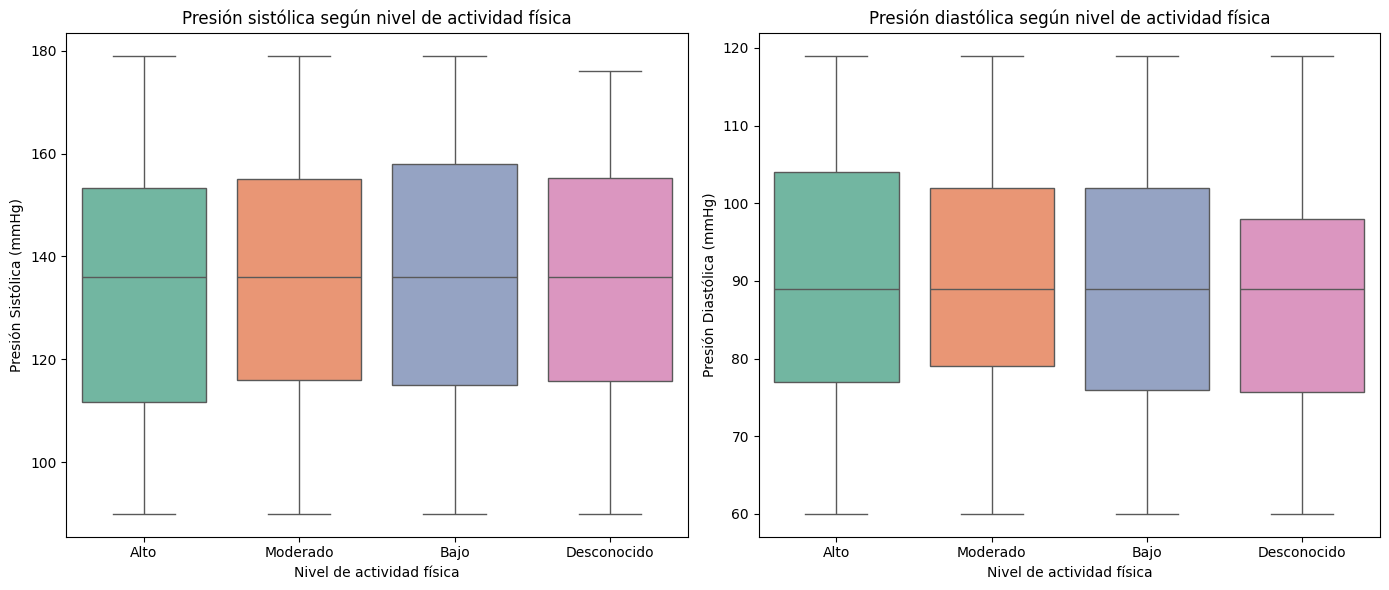

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Ponemos los dos boxplot juntos (diastólica y sistólica)

sns.boxplot(
    data=df_datos_salud_visu,
    x='nivel_actividad',
    y='presion_sistolica',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Presión sistólica según nivel de actividad física')
axes[0].set_xlabel('Nivel de actividad física')
axes[0].set_ylabel('Presión Sistólica (mmHg)')

sns.boxplot(
    data=df_datos_salud_visu,
    x='nivel_actividad',
    y='presion_diastolica',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Presión diastólica según nivel de actividad física')
axes[1].set_xlabel('Nivel de actividad física')
axes[1].set_ylabel('Presión Diastólica (mmHg)')

plt.tight_layout()
plt.show()


### Análisis de la relación entre la presión arterial y el nivel de actividad física

En los gráficos se ve cómo cambia la presión arterial según el nivel de actividad física. Las personas con actividad alta suelen tener presiones más bajas, tanto sistólica como diastólica. En cambio, quienes tienen poca actividad tienden a tener presiones más altas.

Además, no se observan *outliers* significativos en los datos, lo que indica que la mayoría de las personas se mantienen dentro de los valores centrales (cercanos a la **mediana**) 

Esto sugiere que hacer ejercicio o moverse más puede ayudar a mantener la presión arterial en rangos más saludables.

## _3-¿Existe diferencias en el numero de pasos diarios entre fumadores y no fumadores?_

C:\Users\elena\AppData\Local\Temp\ipykernel_5616\1161095767.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fumador', y='pasos_diarios', data=df_datos_salud_visu, estimator='mean', ci=None,palette='Set2')
C:\Users\elena\AppData\Local\Temp\ipykernel_5616\1161095767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fumador', y='pasos_diarios', data=df_datos_salud_visu, estimator='mean', ci=None,palette='Set2')


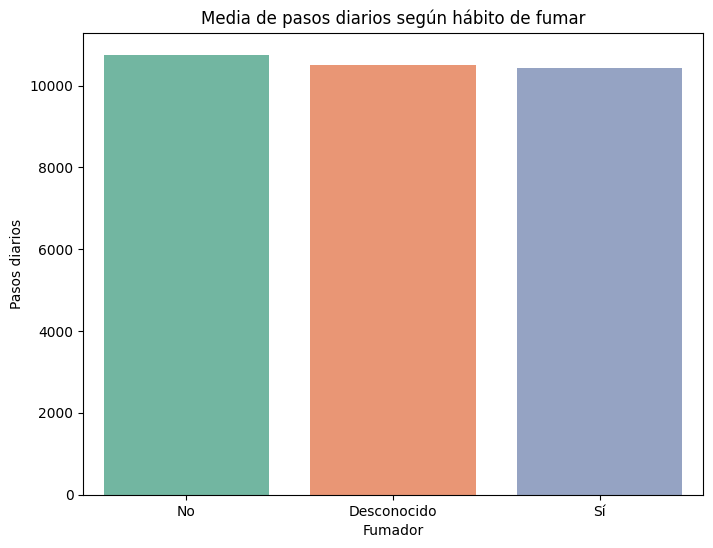

In [26]:
plt.figure(figsize=(8,6))
sns.barplot(x='fumador', y='pasos_diarios', data=df_datos_salud_visu, estimator='mean', ci=None,palette='Set2')
plt.title('Media de pasos diarios según hábito de fumar')
plt.ylabel('Pasos diarios')
plt.xlabel('Fumador')
plt.show()

### **Análisis de pasos diarios entre personas fumadores y no fumadores**

La gráfica compara la media de pasos diarios entre personas **fumadoras**, **no fumadoras** y aquellas cuyo hábito de fumar no está registrado (_Desconocido_). Se observa que el grupo de **no fumadores** realiza, en promedio, más pasos al día que el de **fumadores**, lo que sugiere una mayor tendencia a mantener niveles más altos de actividad física y comportamientos más saludables. El grupo **Desconocido** se sitúa en una posición intermedia, aunque su interpretación es limitada por la falta de información clara sobre el hábito de fumar.

En general, la gráfica muestra que las personas que fuman tienden a caminar menos que las que no, por lo que sí existe difernecia entre el número de pasos de fumadores y no fumadores.

## _4-¿Cómo se relaciono el numero de horas de sueño con la satisfaccion con la vida?_

### Interpretación del coeficiente

| **Rango del coeficiente** | **Interpretación**                | **Tipo de relación**                |
|---------------------------|-----------------------------------|------------------------------------|
| 1.0                       | Correlación perfecta positiva      | Cuanto más sube una variable, más sube la otra |
| 0.7 a 0.9                 | Correlación positiva fuerte        | Relación positiva clara            |
| 0.4 a 0.6                 | Correlación positiva moderada      | Relación positiva moderada         |
| 0.1 a 0.3                 | Correlación positiva débil         | Relación positiva débil            |
| 0.0                       | Sin correlación                   | No hay relación aparente           |
| -0.1 a -0.3               | Correlación negativa débil         | Relación negativa débil            |
| -0.4 a -0.6               | Correlación negativa moderada      | Relación negativa moderada         |
| -0.7 a -0.9               | Correlación negativa fuerte        | Relación negativa clara            |
| -1.0                      | Correlación perfecta negativa      | Cuanto más sube una variable, más baja la otra |

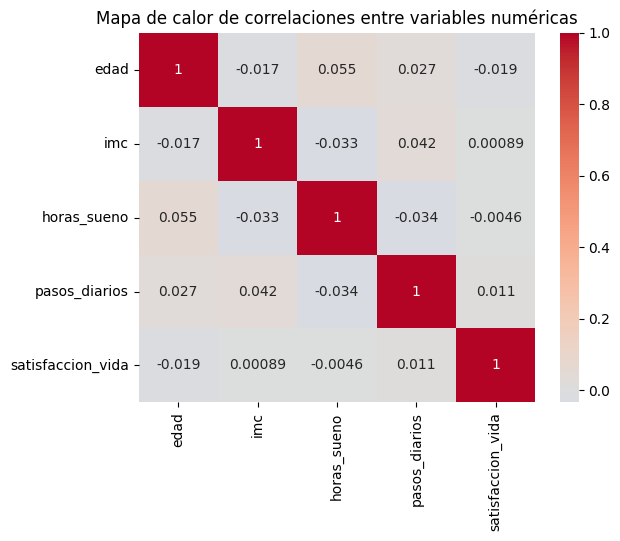

In [27]:
# Selecciona solo columnas numéricas

cols_num = ['edad', 'imc', 'horas_sueno', 'pasos_diarios', 'satisfaccion_vida']
# Calcula la matriz de correlación

corr = df_datos_salud_visu[cols_num].corr()

#visualización del heatmap con las columnas numericas

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,)
plt.title('Mapa de calor de correlaciones entre variables numéricas')
plt.show()

C:\Users\elena\AppData\Local\Temp\ipykernel_5616\527565650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


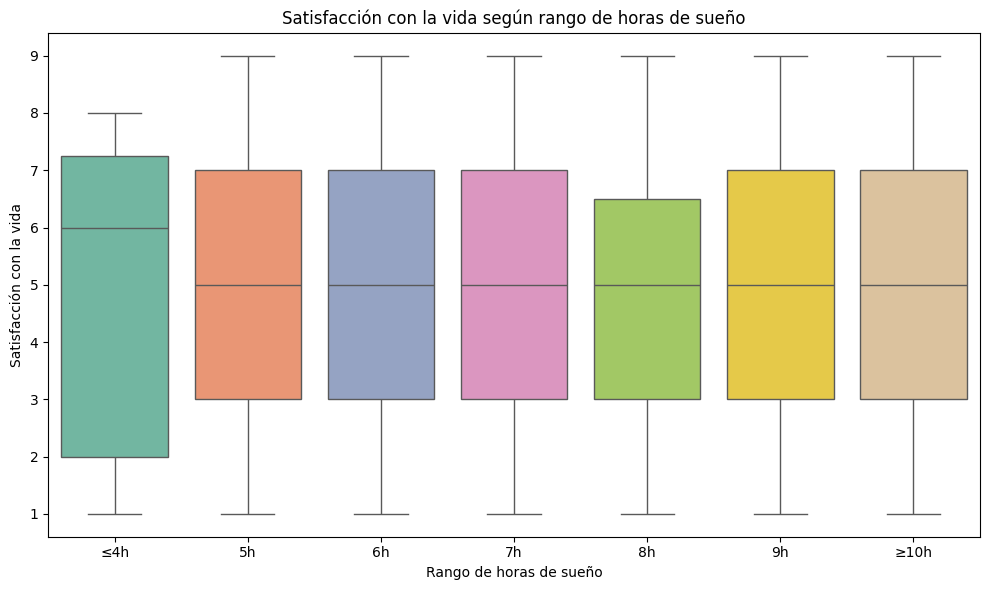

In [28]:
bins = [0, 4, 5, 6, 7, 8, 9, 24]
labels = ['≤4h', '5h', '6h', '7h', '8h', '9h', '≥10h']

# Agrupo
df_datos_salud_visu['grupo_horas_sueno'] = pd.cut(df_datos_salud_visu['horas_sueno'], bins=bins, labels=labels)

# Gafica
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_datos_salud_visu,
    x='grupo_horas_sueno',
    y='satisfaccion_vida',
    palette='Set2'
)
plt.title('Satisfacción con la vida según rango de horas de sueño')
plt.xlabel('Rango de horas de sueño')
plt.ylabel('Satisfacción con la vida')
plt.tight_layout()
plt.show()

### **Análisis de horas de sueño y satisfacción con la vida**

Los resultados muestran que **no existe una relación clara entre las horas de sueño y la satisfacción con la vida**.  

El **mapa de calor** refleja una correlación casi nula (**0.008**), y el **boxplot** confirma que los niveles de satisfacción se mantienen similares en todos los rangos de sueño. 

Aunque el grupo que duerme menos de 4 horas presenta más variabilidad, no sigue un patrón lógico ni consistente.  

En conclusión, **las horas de sueño no parecen influir significativamente en la satisfacción vital** dentro de esta muestra.


## _5-¿Qué proporción de personas que consumen alcohol pertenece a cada género?_

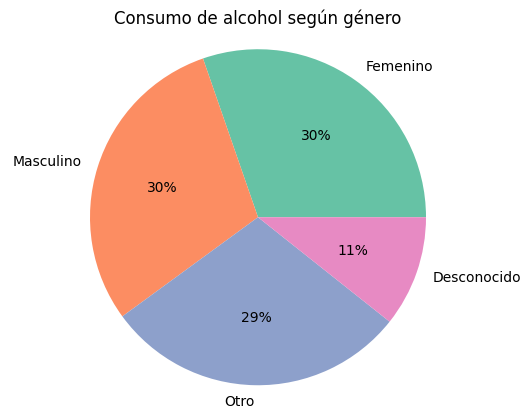

In [29]:
alcohol_g = df_datos_salud_visu[df_datos_salud_visu['consumo_alcohol'] != 'Nunca']['genero'].value_counts()

categoria = alcohol_g.index

plt.pie(alcohol_g, labels=categoria, autopct='%1.0f%%', colors=sns.color_palette('Set2'))
plt.title('Consumo de alcohol según género')
plt.axis('equal')
plt.show()

### **Análisis de consumo de alcohol según género**

La gráfica muestra cómo se distribuye el consumo de alcohol entre los distintos géneros. En este caso, se observa que la proporción de mujeres y hombres que consumen alcohol es similar con porcentajes iguales. También hay un grupo de personas con género no especificado o distinto, que representa el resto (siendo "Otro" un 29% y "Desconocido" un 11%).

Esto indica que, al menos en esta base de datos, el hábito de consumir alcohol no parece estar muy marcado por el género.

## _6-¿Cómo varía el IMC con la edad?_

C:\Users\elena\AppData\Local\Temp\ipykernel_5616\1908220423.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


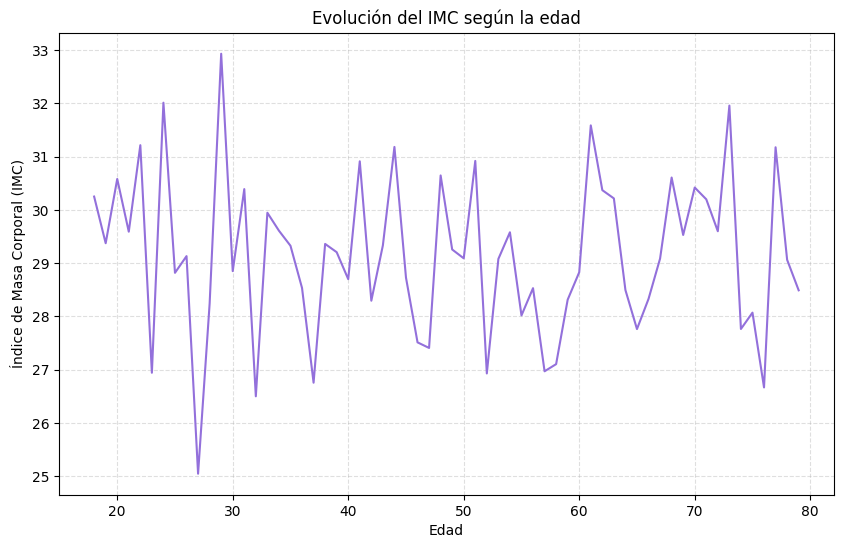

In [30]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_datos_salud_visu,
    x='edad',
    y='imc',
    ci=None,
    color='mediumpurple'
)

plt.title('Evolución del IMC según la edad')
plt.xlabel('Edad')
plt.ylabel('Índice de Masa Corporal (IMC)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()



### **Análisis de la relación entre el IMC y la edad**

El gráfico muestra que **el IMC tiende a aumentar con la edad**, especialmente durante la adultez, esto puede deberse a una **menor actividad física** y **cambios en el metabolismo** con el paso del tiempo.  
En edades más avanzadas, el IMC parece **estabilizarse o bajar ligeramente**, probablemente por la **pérdida de masa corporal**. En general, se observa una **relación moderada y positiva entre la edad y el IMC**.
